# Optimal Transport in linear Independent Component Analysis (ICA)
#### Here, We validate OT-ICA Methodology in a simple 4 dimensional case of ICA.

In [4]:
import numpy as np
import torch
import pandas as pd
import scipy.stats
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from sklearn.decomposition import FastICA
import warnings
from sklearn.exceptions import ConvergenceWarning

from wasserstein_ica import WassersteinICA

In [5]:
    # Define a consistent Thesis Theme
    def set_thesis_theme():
        # Academic, colorblind-friendly palette
        # Blue, Orange, Green, Red, Purple, Brown
        thesis_colors = ['#0173B2', '#DE8F05', '#029E73', '#D55E00', '#CC78BC', '#CA9161']
        
        mpl.rcParams.update({
            # Figure and Layout
            'figure.figsize': (8, 5),
            'figure.dpi': 300,            # High resolution for print
            'axes.prop_cycle': mpl.cycler(color=thesis_colors),
            
            # Grid lines (light and unobtrusive)
            'axes.grid': True,
            'grid.alpha': 0.3,
            'grid.linestyle': '--',
            'axes.axisbelow': True,       # Grid goes behind data
            
            # Spines (remove top and right borders for a cleaner look)
            'axes.spines.top': False,
            'axes.spines.right': False,
            
            # Fonts and Text
            'font.size': 11,
            'axes.titlesize': 13,
            'axes.labelsize': 12,
            'xtick.labelsize': 10,
            'ytick.labelsize': 10,
            
            # Legends
            'legend.frameon': False,      # No box around the legend
            'legend.fontsize': 10,
            
            # Lines
            'lines.linewidth': 2.0
        })

    # Run this before plotting
    set_thesis_theme()

In [6]:
def amari_error(W_est, A_true):
    if W_est is None or np.any(np.isnan(W_est)):
        return np.nan
    P = np.abs(W_est @ A_true)
    n = P.shape[0]
    row_sum = np.sum(P, axis=1)
    row_max = np.max(P, axis=1)
    term1 = np.sum((row_sum / row_max) - 1)
    col_sum = np.sum(P, axis=0)
    col_max = np.max(P, axis=0)
    term2 = np.sum((col_sum / col_max) - 1)
    return (term1 + term2) / (2 * n)

In [7]:
# ==========================================
# 1. Simulation Setup (4 Dimensions)
# ==========================================
n_samples = 10000
n_sources = 4
np.random.seed(42)
torch.manual_seed(42)

# Source 1: Laplace (Super-Gaussian, sharp peak)
s1 = np.random.laplace(0, 1, n_samples)
# Source 2: Uniform (Sub-Gaussian, flat)
s2 = np.random.uniform(-np.sqrt(3), np.sqrt(3), n_samples)
# Source 3: Student-t (Heavy tails, df=3)
s3 = np.random.standard_t(df=3, size=n_samples)
# Source 4: Beta(0.5, 0.5) (U-shaped, Bimodal)
s4 = np.random.beta(0.5, 0.5, size=n_samples)

# Stack, Center, and Normalize
S_true = np.stack([s1, s2, s3, s4])
S_true = (S_true - np.mean(S_true, axis=1, keepdims=True)) / np.std(S_true, axis=1, keepdims=True)
source_names = ['Laplace', 'Uniform', 'Student-t', 'Beta']

# Random well-conditioned Mixing Matrix
A_true = np.random.randn(n_sources, n_sources)
while np.linalg.cond(A_true) > 20:
    A_true = np.random.randn(n_sources, n_sources)

X_mixed = A_true @ S_true
X_torch = torch.tensor(X_mixed, dtype=torch.float32)

print("--- Ground Truth Mixing Matrix (A) ---")
print(np.round(A_true, 3))

--- Ground Truth Mixing Matrix (A) ---
[[ 1.058  1.52  -0.249  1.012]
 [ 0.042 -0.486  0.388 -0.523]
 [-0.154 -1.572 -0.304 -1.234]
 [-0.006  0.503  0.053  0.928]]


In [8]:
# ==========================================
# 2. Wasserstein ICA Extraction (Stiefel)
# ==========================================
print("\n--- Running W2-ICA ---")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
ica = WassersteinICA(X_torch.to(device))
ica.whiten()
W_white_np = ica.W_white.cpu().numpy()

# 2.1 Deflation Initialization
extracted_ws = []
for i in range(n_sources):
    prev = torch.stack(extracted_ws) if extracted_ws else None
    w, _ = ica.optimize_wasserstein2(
        prev_components=prev, 
        max_iter=200, 
        n_restarts=50,
        dither_sigma=0.01 # Crucial for Bernoulli
    )
    extracted_ws.append(w)

W_deflation_init = torch.stack(extracted_ws)

# 2.2 Symmetric Stiefel Polish
W_stiefel_unmixed = ica.optimize_symmetric(
    n_components=n_sources, 
    max_iter=400,        
    lr=0.25,             
    init_w=W_deflation_init, 
    optimizer='stiefel',
    dither_sigma=0.01,   
    batch_size=1024      
)

W_wass_total = W_stiefel_unmixed.cpu().numpy() @ W_white_np
score_wass = amari_error(W_wass_total, A_true)

print("\n--- Estimated Unmixing Matrix (W_est) ---")
print(np.round(W_wass_total, 3))
print(f"\nW2-ICA Amari Error: {score_wass:.5f}")


--- Running W2-ICA ---

--- Estimated Unmixing Matrix (W_est) ---
[[ 0.152 -1.943  0.608 -0.455]
 [ 0.092  0.284  0.633  1.978]
 [-0.147 -0.723 -1.096 -1.692]
 [-1.021 -1.2   -0.828 -0.674]]

W2-ICA Amari Error: 0.01677


In [9]:
# 2.3 FastICA Extraction (For Comparison)
print("\n--- Running FastICA ---")
with warnings.catch_warnings():
    warnings.filterwarnings("ignore", category=ConvergenceWarning)
    # FastICA expects shape (n_samples, n_features) so we transpose X_mixed
    fast_ica = FastICA(n_components=n_sources, max_iter=1000, random_state=42)
    fast_ica.fit(X_mixed.T)

# In sklearn, components_ is the full unmixing matrix W (such that S = W @ X)
W_fastica_total = fast_ica.components_
score_fast = amari_error(W_fastica_total, A_true)

print(f"FastICA Amari Error: {score_fast:.5f}")


--- Running FastICA ---
FastICA Amari Error: 0.01879


In [10]:
# ==========================================
# 3. Source Matching & Global Transfer Matrices
# ==========================================

# 3.1 OT-ICA Global Transfer Matrix P = W_est @ A_true
P_wass = W_wass_total @ A_true
print("\n--- OT-ICA Global Transfer Matrix (P) ---")
print(np.round(P_wass, 3))

matches = []
for i in range(n_sources):
    row_abs = np.abs(P_wass[i])
    best_match_idx = np.argmax(row_abs)
    sign = np.sign(P_wass[i, best_match_idx])
    matches.append({
        "extracted_idx": i,
        "original_idx": best_match_idx,
        "name": source_names[best_match_idx],
        "sign": sign
    })

# 3.2 FastICA Global Transfer Matrix P = W_est @ A_true
P_fast = W_fastica_total @ A_true
print("\n--- FastICA Global Transfer Matrix (P) ---")
print(np.round(P_fast, 3))


--- OT-ICA Global Transfer Matrix (P) ---
[[-0.012 -0.009 -1.    -0.003]
 [-0.     0.003 -0.001  1.   ]
 [-0.007  1.    -0.     0.012]
 [-1.    -0.007  0.005 -0.01 ]]

--- FastICA Global Transfer Matrix (P) ---
[[-1.    -0.012  0.003 -0.008]
 [ 0.012 -1.     0.001 -0.004]
 [-0.002 -0.01  -0.001 -1.   ]
 [-0.01  -0.01  -1.    -0.001]]


Successfully saved huge figure to otica_baseline_recovery.pdf


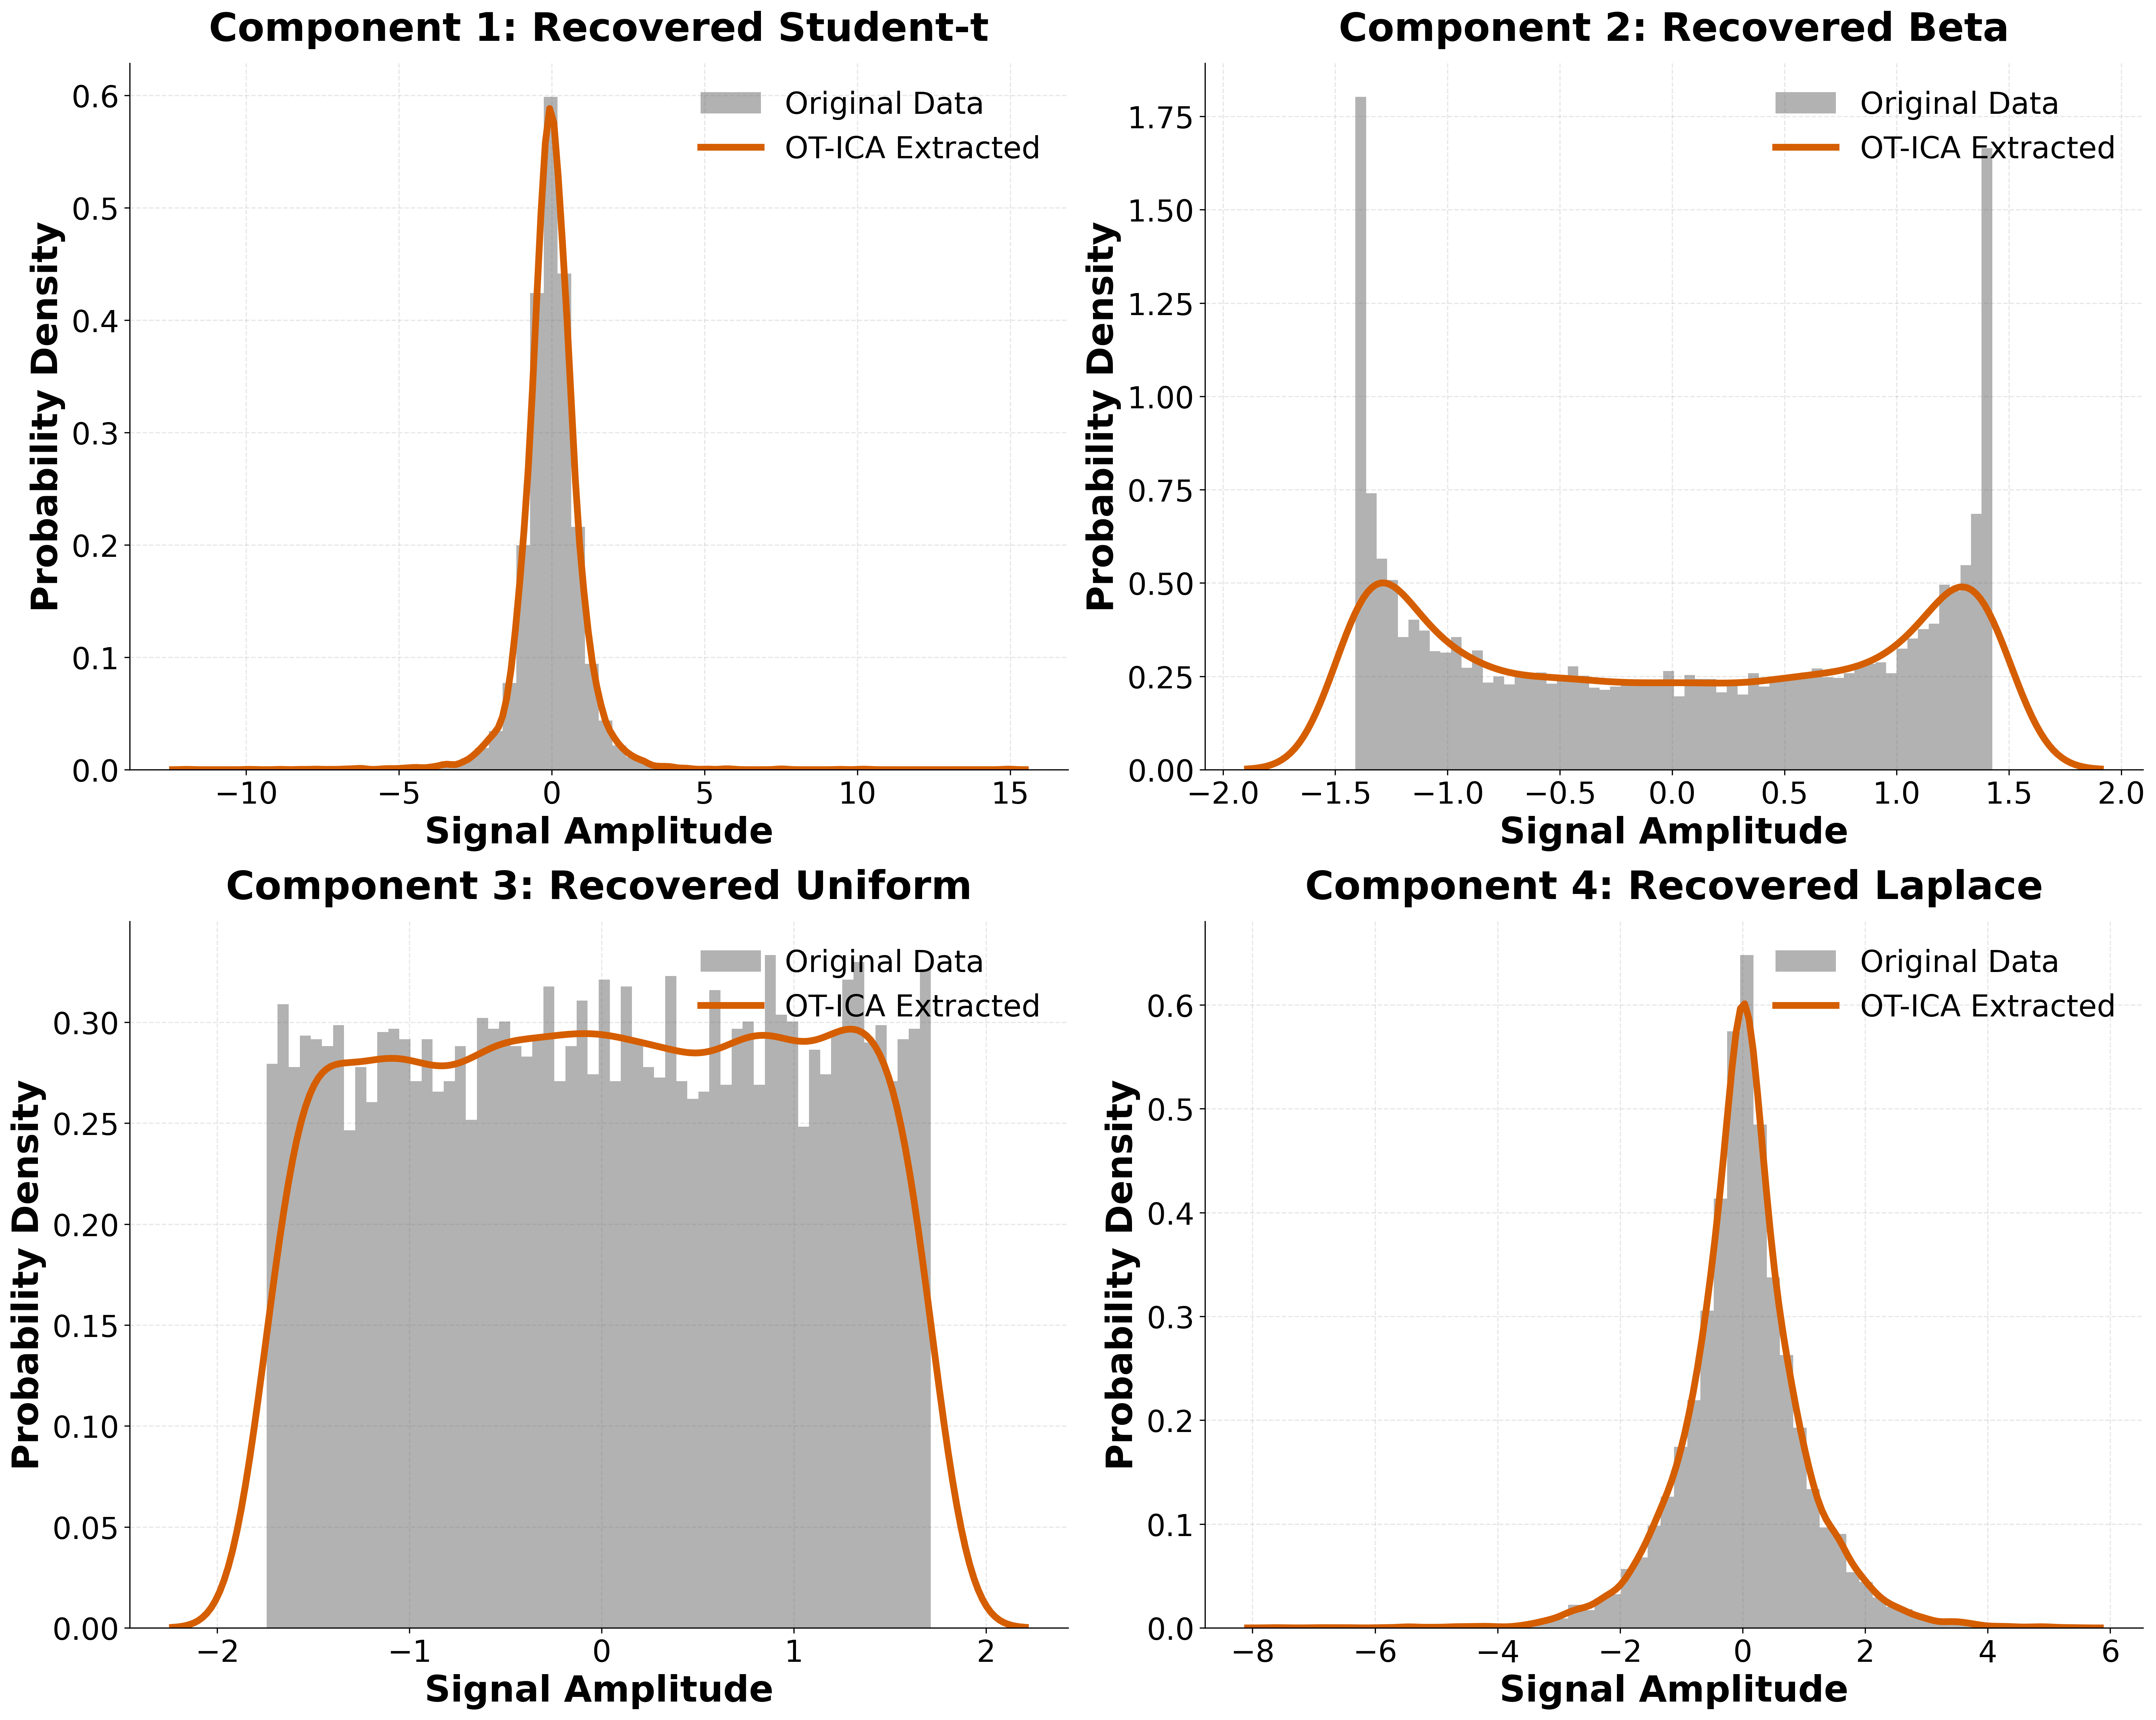

In [11]:
# Extract Signals
Y_est = W_wass_total @ X_mixed

# ==========================================
# 4. Visualization (Massive PDF Export)
# ==========================================
# Set up a massive figure size for high-quality downscaling
fig, axes = plt.subplots(2, 2, figsize=(20, 16))
axes = axes.flatten()

for m in matches:
    i = m['extracted_idx']
    j = m['original_idx']
    sign = m['sign']
    
    orig = S_true[j]
    est = Y_est[i] * sign # Fix sign flip
    
    ax = axes[i]
    
    # Darker Gray Histogram Bars for Original Data (No shading)
    ax.hist(orig, bins=60, density=True, alpha=0.5, color='#666666', edgecolor='none', label='Original Data')
    
    # Sharp Orange Line for Extracted Data (OT-ICA Reserved Color)
    sns.kdeplot(est, ax=ax, color='#D55E00', linewidth=4.5, label='OT-ICA Extracted')
        
    # Doubled font sizes for Title, Labels, and Ticks
    ax.set_title(f"Component {i+1}: Recovered {m['name']}", fontsize=26, fontweight='bold', pad=15)
    ax.set_xlabel("Signal Amplitude", fontsize=24, fontweight='bold')
    ax.set_ylabel("Probability Density", fontsize=24, fontweight='bold')
    
    ax.tick_params(axis='both', which='major', labelsize=20)
    
    # Doubled legend size
    ax.legend(loc='upper right', fontsize=20, frameon=False)
    ax.grid(True, alpha=0.3)

plt.tight_layout()

# Save as a high-quality PDF specifically for LaTeX rendering
file_name = 'otica_baseline_recovery.pdf'
plt.savefig(file_name, format='pdf', bbox_inches='tight')
print(f"Successfully saved huge figure to {file_name}")

plt.show()

## Comparison: Wasserstein versus FAST ICA using Amari Similarity measure

- P = U.M, where U is unmixing and M is mixing matrix and P should ideally have only one non zero entry per row

**The Formula**
$$
E_{Amari} = \frac{1}{2n(n-1)} \left[ \sum_{i=1}^{n} \left( \frac{\sum_{j=1}^{n} |g_{ij}|}{\max_j |g_{ij}|} - 1 \right) + \sum_{j=1}^{n} \left( \frac{\sum_{i=1}^{n} |g_{ij}|}{\max_i |g_{ij}|} - 1 \right) \right]
$$

**Simon's Correction**
$$
E_{Amari} = \frac{1}{2n} \left[ \sum_{i=1}^{n} \left( \frac{\sum_{j=1}^{n} |g_{ij}|}{\max_j |g_{ij}|} - 1 \right) + \sum_{j=1}^{n} \left( \frac{\sum_{i=1}^{n} |g_{ij}|}{\max_i |g_{ij}|} - 1 \right) \right]
$$

**Interpretation**
* **0.0**: Perfect Separation (The matrices match exactly up to permutation/scale).
* **< 0.4**: Good/Acceptable Separation.
* **> 0.5**: Poor Separation (Failed to unmix).

In [12]:
from sklearn.decomposition import FastICA


# ==========================================
# 4. Method 2: FastICA (sklearn)
# ==========================================
print("\n--- Running FastICA (sklearn) ---")
# FastICA expects shape (n_samples, n_features)
X_sklearn = X_mixed.T 

# Algorithm 1: Parallel FastICA with logcosh (approx Negentropy)
fastica = FastICA(n_components=n_sources, algorithm='parallel', fun='logcosh', random_state=42)
S_est_fast = fastica.fit_transform(X_sklearn)
W_total_fastica = fastica.components_ #@ fastica.whitening_ # Total unmixing matrix

score_fastica = amari_error(W_total_fastica, A_true)
print(f"FastICA (logcosh) Amari Error: {score_fastica:.5f}")


--- Running FastICA (sklearn) ---
FastICA (logcosh) Amari Error: 0.01879
